# 02 · Exploratory Data Analysis

Three families of analysis:

1. **Time trends** — monthly volume, year-over-year growth, seasonality, peak months
2. **Exchange funnel** — `APP → ACH → ACC → APD → RE → FI → CO`, conversion and drop-off
3. **Entity / product** — LC performance, programme performance, monthly contribution

In [1]:
import sys, warnings
from pathlib import Path

# Make the project root importable when running from notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

from src.config import get_settings, configure_logging

settings = get_settings()
configure_logging(settings, "WARNING")
print("Project root:", ROOT)
print("MC:", settings.mc_name, "| target:", settings.target, "| forecast year:", settings.forecast_year)

Project root: /Users/jayedalammansur/Exchange Activity Prediction Platform
MC: AIESEC in India | target: APP | forecast year: 2026


In [2]:
from src.preprocessing.cleaning import load_exchange_dataset
from src.preprocessing import analysis

panel = load_exchange_dataset(settings)
target = settings.target
print(panel.shape)
panel.head(3)

(5760, 16)


,date,year,month,month_name,quarter,entity,product,direction,programme,APP,ACH,ACC,APD,RE,FI,CO
0,2022-01-01,2022,1,Jan,1,AIESEC in Ahmedabad,GTa,incoming,iGTa,3,1,1,1,1,1,1
1,2022-01-01,2022,1,Jan,1,AIESEC in Ahmedabad,GTe,incoming,iGTe,0,0,0,0,0,0,0
2,2022-01-01,2022,1,Jan,1,AIESEC in Ahmedabad,GV,incoming,iGV,5,3,0,0,0,0,0


## 1. Monthly trend

In [3]:
trend = analysis.monthly_trend(panel, settings)
trend[["period", target, "mom_growth_pct", "yoy_growth_pct", "rolling_12m", "app_to_re_pct"]].tail(12).round(2)

,period,APP,mom_growth_pct,yoy_growth_pct,rolling_12m,app_to_re_pct
36,2025-01,1676,-15.18,13.55,1448.58,21.66
37,2025-02,1138,-32.10,6.16,1454.08,21.88
38,2025-03,1309,15.03,16.77,1469.75,21.01
39,2025-04,1353,3.36,8.94,1479.00,21.73
40,2025-05,1702,25.79,1.01,1480.42,21.45
41,2025-06,1894,11.28,14.37,1500.25,20.43
42,2025-07,1510,-20.27,6.64,1508.08,21.52
43,2025-08,1315,-12.91,3.06,1511.33,20.08
44,2025-09,1331,1.22,-0.45,1510.83,21.11
45,2025-10,1482,11.34,6.24,1518.08,20.85


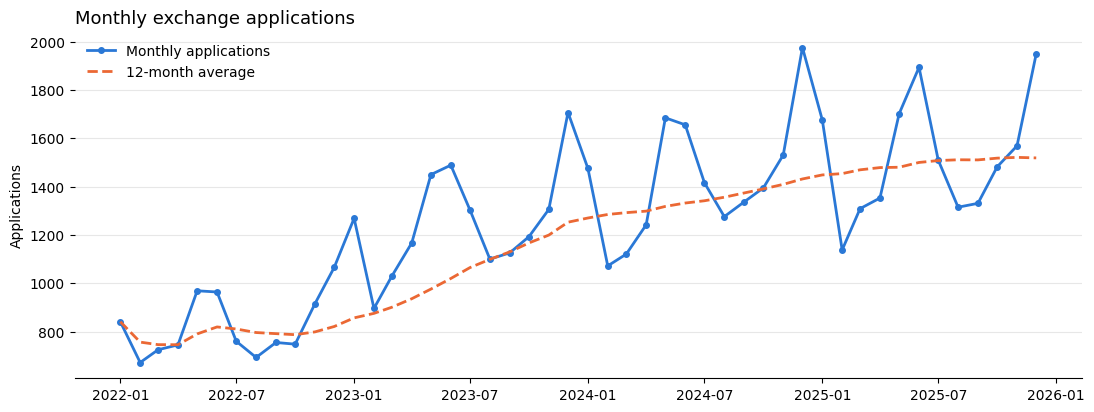

In [4]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(trend["date"], trend[target], marker="o", markersize=4, linewidth=2,
        color="#2a78d6", label="Monthly applications")
ax.plot(trend["date"], trend["rolling_12m"], linestyle="--", linewidth=2,
        color="#eb6834", label="12-month average")
ax.set_title("Monthly exchange applications", loc="left", fontsize=13)
ax.set_ylabel("Applications")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
plt.show()

## 2. Yearly growth

In [5]:
yearly = analysis.yearly_summary(panel, settings)
yearly

,year,total_applications,avg_monthly_applications,peak_month_applications,min_month_applications,std_monthly_applications,months_observed,total_realizations,app_to_re_pct,yoy_growth_pct,peak_month
0,2022,9854,821.17,1066,672,127.49,12,1715,17.40,NaN,Dec
1,2023,15036,1253.00,1707,896,220.31,12,2742,18.24,52.59,Dec
2,2024,17183,1431.92,1976,1072,255.71,12,3394,19.75,14.28,Dec
3,2025,18229,1519.08,1950,1138,249.04,12,3859,21.17,6.09,Dec


In [6]:
first, last = yearly.iloc[0], yearly.iloc[-1]
years = int(last["year"]) - int(first["year"])
cagr = ((last["total_applications"] / first["total_applications"]) ** (1 / years) - 1) * 100
print(f"{int(first['year'])} -> {int(last['year'])}")
print(f"  total growth: {(last['total_applications'] / first['total_applications'] - 1) * 100:.1f}%")
print(f"  CAGR        : {cagr:.1f}%")

2022 -> 2025
  total growth: 85.0%
  CAGR        : 22.8%


## 3. Seasonality

The seasonal index expresses each calendar month relative to the overall monthly mean:
`1.20` means that month typically runs 20% above average.

In [7]:
profile = analysis.seasonality_profile(panel, settings)
profile[["month_name", "mean_applications", "seasonal_index", "season_label"]]

,month_name,mean_applications,seasonal_index,season_label
0,Jan,1315.50,1.047,Medium
1,Feb,944.50,0.752,Low
2,Mar,1046.25,0.833,Low
3,Apr,1126.75,0.897,Medium
4,May,1451.50,1.155,High
5,Jun,1500.75,1.195,High
6,Jul,1247.25,0.993,Medium
7,Aug,1096.00,0.872,Low
8,Sep,1137.25,0.905,Medium
9,Oct,1204.50,0.959,Medium


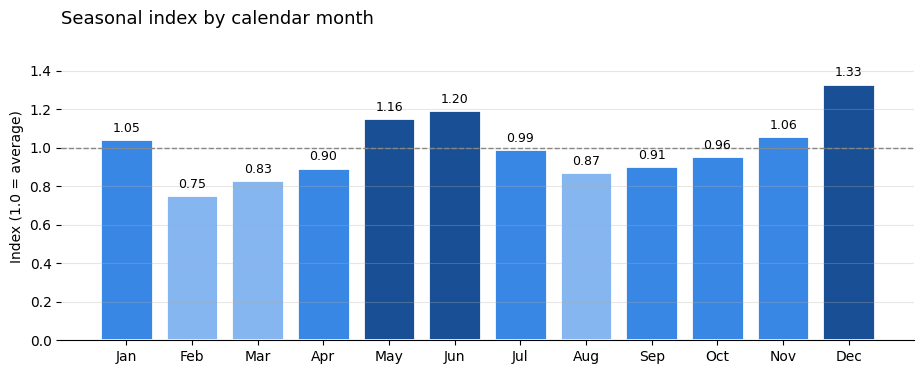

High months: ['May', 'Jun', 'Dec']
Low months : ['Feb', 'Mar', 'Aug']
Peak/trough swing: 1.77x


In [8]:
fig, ax = plt.subplots(figsize=(11, 4))
colors = ["#184f95" if s == "High" else "#86b6ef" if s == "Low" else "#3987e5"
          for s in profile["season_label"]]
bars = ax.bar(profile["month_name"], profile["seasonal_index"], color=colors,
              edgecolor="white", linewidth=2)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
ax.axhline(1.0, color="#898781", linestyle="--", linewidth=1)
ax.set_title("Seasonal index by calendar month", loc="left", fontsize=13)
ax.set_ylabel("Index (1.0 = average)")
ax.set_ylim(0, profile["seasonal_index"].max() * 1.2)
ax.grid(axis="y", alpha=0.3)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
plt.show()

high = profile[profile["season_label"] == "High"]["month_name"].tolist()
low = profile[profile["season_label"] == "Low"]["month_name"].tolist()
print("High months:", high)
print("Low months :", low)
print(f"Peak/trough swing: {profile['seasonal_index'].max() / profile['seasonal_index'].min():.2f}x")

## 4. Peak months on record

In [9]:
analysis.peak_months(panel, top_n=10, settings=settings)

,rank,month,applications
0,1,Dec 2024,1976
1,2,Dec 2025,1950
2,3,Jun 2025,1894
3,4,Dec 2023,1707
4,5,May 2025,1702
5,6,May 2024,1685
6,7,Jan 2025,1676
7,8,Jun 2024,1656
8,9,Nov 2025,1569
9,10,Nov 2024,1531


## 5. Year-on-year comparison

Normalising each year to 100% removes the growth trend, isolating the seasonal shape so
years can be compared directly.

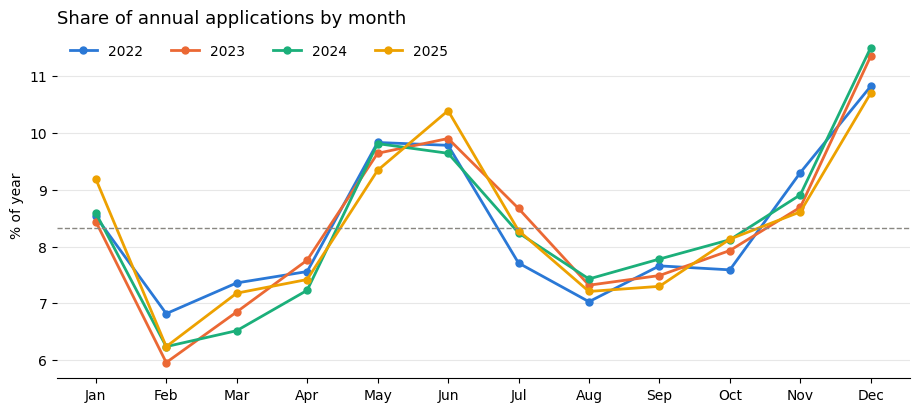

In [10]:
contribution = analysis.monthly_contribution(panel, settings)

fig, ax = plt.subplots(figsize=(11, 4.5))
palette = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
for index, year in enumerate(sorted(contribution["year"].unique())):
    subset = contribution[contribution["year"] == year].sort_values("month")
    ax.plot(subset["month"], subset["contribution_pct"], marker="o", markersize=5,
            linewidth=2, color=palette[index % len(palette)], label=str(year))
ax.axhline(100 / 12, color="#898781", linestyle="--", linewidth=1)
ax.set_xticks(range(1, 13))
ax.set_xticklabels([pd.Timestamp(2024, m, 1).strftime("%b") for m in range(1, 13)])
ax.set_title("Share of annual applications by month", loc="left", fontsize=13)
ax.set_ylabel("% of year")
ax.legend(frameon=False, ncols=4)
ax.grid(axis="y", alpha=0.3)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
plt.show()

## 6. The exchange funnel

- `conversion_from_previous_pct` — share of the *previous* stage that advanced. The operational lever.
- `conversion_from_APP_pct` — cumulative efficiency from application.
- `dropoff_count` — absolute volume lost at this step.

In [11]:
funnel = analysis.funnel_analysis(panel, settings)
funnel

,stage_order,stage,stage_label,count,conversion_from_previous_pct,conversion_from_APP_pct,dropoff_count,dropoff_pct,is_biggest_dropoff
0,1,APP,Applied,60302,100.00,100.00,0,0.00,False
1,2,ACH,Achieved / Matched,26723,44.32,44.32,33579,55.68,True
2,3,ACC,Accepted,18607,69.63,30.86,8116,30.37,False
3,4,APD,Approved,15267,82.05,25.32,3340,17.95,False
4,5,RE,Realized,11710,76.70,19.42,3557,23.30,False
5,6,FI,Finished,11109,94.87,18.42,601,5.13,False
6,7,CO,Completed,10236,92.14,16.97,873,7.86,False


In [12]:
worst = funnel.iloc[1:].loc[funnel.iloc[1:]["dropoff_count"].idxmax()]
upstream = funnel.iloc[int(worst["stage_order"]) - 2]
realized = funnel[funnel["stage"] == "RE"].iloc[0]

print(f"Largest leak : {upstream['stage']} -> {worst['stage']}")
print(f"  lost       : {int(worst['dropoff_count']):,} ({worst['dropoff_pct']:.1f}% of {upstream['stage']})")
print(f"\nEnd-to-end   : {realized['conversion_from_APP_pct']:.1f}% of applications realize")
print(f"  i.e. ~{100 / realized['conversion_from_APP_pct']:.1f} applications per realization")

Largest leak : APP -> ACH
  lost       : 33,579 (55.7% of APP)

End-to-end   : 19.4% of applications realize
  i.e. ~5.1 applications per realization


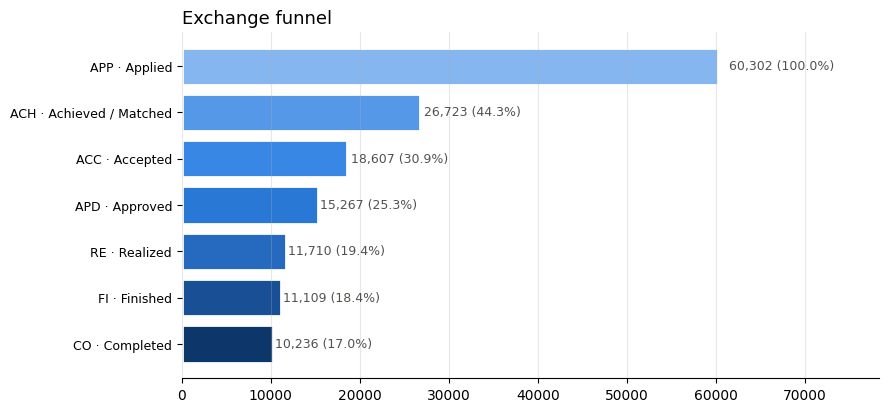

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))
positions = np.arange(len(funnel))[::-1]
ramp = ["#86b6ef", "#5598e7", "#3987e5", "#2a78d6", "#256abf", "#184f95", "#0d366b"]
ax.barh(positions, funnel["count"], color=ramp[:len(funnel)], edgecolor="white", linewidth=2)
for position, row in zip(positions, funnel.itertuples()):
    ax.text(row.count * 1.02, position, f"{row.count:,} ({row.conversion_from_APP_pct:.1f}%)",
            va="center", fontsize=9, color="#52514e")
ax.set_yticks(positions)
ax.set_yticklabels([f"{r.stage} · {r.stage_label}" for r in funnel.itertuples()], fontsize=9)
ax.set_xlim(0, funnel["count"].max() * 1.3)
ax.set_title("Exchange funnel", loc="left", fontsize=13)
ax.grid(axis="x", alpha=0.3)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
plt.show()

### Funnel efficiency by programme and by year

In [14]:
display(analysis.funnel_by_dimension(panel, "programme", settings).round(2))
display(analysis.funnel_by_dimension(panel, "year", settings).round(2))

,programme,APP,ACH,ACC,APD,RE,FI,CO,conv_APP_to_ACH_pct,conv_ACH_to_ACC_pct,conv_ACC_to_APD_pct,conv_APD_to_RE_pct,conv_RE_to_FI_pct,conv_FI_to_CO_pct,app_to_re_pct,app_to_co_pct
0,oGV,30879,13599,9343,7506,5591,5304,4822,44.04,68.70,80.34,74.49,94.87,90.91,18.11,15.62
1,iGV,10693,4347,2784,2097,1480,1333,1125,40.65,64.04,75.32,70.58,90.07,84.40,13.84,10.52
2,oGTa,10477,5124,3893,3483,2913,2805,2707,48.91,75.98,89.47,83.63,96.29,96.51,27.80,25.84
3,iGTa,3628,1587,1171,1002,792,765,725,43.74,73.79,85.57,79.04,96.59,94.77,21.83,19.98
4,oGTe,3487,1569,1112,939,752,731,705,45.00,70.87,84.44,80.09,97.21,96.44,21.57,20.22
5,iGTe,1138,497,304,240,182,171,152,43.67,61.17,78.95,75.83,93.96,88.89,15.99,13.36


,year,APP,ACH,ACC,APD,RE,FI,CO,conv_APP_to_ACH_pct,conv_ACH_to_ACC_pct,conv_ACC_to_APD_pct,conv_APD_to_RE_pct,conv_RE_to_FI_pct,conv_FI_to_CO_pct,app_to_re_pct,app_to_co_pct
0,2025,18229,8171,5851,4906,3859,3698,3462,44.82,71.61,83.85,78.66,95.83,93.62,21.17,18.99
1,2024,17183,7612,5356,4384,3394,3230,2996,44.30,70.36,81.85,77.42,95.17,92.76,19.75,17.44
2,2023,15036,6603,4520,3685,2742,2589,2351,43.91,68.45,81.53,74.41,94.42,90.81,18.24,15.64
3,2022,9854,4337,2880,2292,1715,1592,1427,44.01,66.41,79.58,74.83,92.83,89.64,17.40,14.48


## 7. Entity (Local Committee) performance

In [15]:
entities = analysis.entity_analysis(panel, settings)
entities.head(12).round(2)

,rank,entity,APP,ACH,ACC,APD,RE,FI,CO,mc_share_pct,app_to_re_pct,avg_monthly_applications,consistency_cv,growth_pct,growth_period
0,1,AIESEC in Delhi IIT,10611,4622,3225,2664,2094,2004,1852,17.60,19.73,221.1,0.28,74.1,2022->2025
1,2,AIESEC in Delhi University,6125,2728,1859,1510,1152,1100,1017,10.16,18.81,127.6,0.31,95.2,2022->2025
2,3,AIESEC in Mumbai,5265,2318,1637,1384,1069,1002,937,8.73,20.30,109.7,0.30,81.5,2022->2025
3,4,AIESEC in Pune,4310,1946,1347,1111,840,800,750,7.15,19.49,89.8,0.29,91.7,2022->2025
4,5,AIESEC in Chennai,3502,1586,1116,933,697,669,599,5.81,19.90,73.0,0.30,83.3,2022->2025
5,6,AIESEC in Bangalore,3099,1369,928,770,575,548,504,5.14,18.55,64.6,0.32,100.4,2022->2025
6,7,AIESEC in Hyderabad,3071,1346,934,753,577,546,498,5.09,18.79,64.0,0.31,71.1,2022->2025
7,8,AIESEC in Kolkata,2773,1225,867,706,555,523,484,4.60,20.01,57.8,0.30,92.2,2022->2025
8,9,AIESEC in Lucknow,2234,972,636,510,381,357,336,3.70,17.05,46.5,0.30,100.0,2022->2025
9,10,AIESEC in Jaipur,2194,965,698,560,434,418,377,3.64,19.78,45.7,0.29,88.5,2022->2025


In [16]:
top5 = entities.head(5)["mc_share_pct"].sum()
print(f"Top 5 LCs generate {top5:.1f}% of all applications")
print(f"Top 10 LCs generate {entities.head(10)['mc_share_pct'].sum():.1f}%")
print(f"\nMost efficient LC: {entities.loc[entities['app_to_re_pct'].idxmax(), 'entity']} "
      f"({entities['app_to_re_pct'].max():.1f}% APP->RE)")

Top 5 LCs generate 49.5% of all applications
Top 10 LCs generate 71.6%

Most efficient LC: AIESEC in Bhubaneswar (21.7% APP->RE)


## 8. Product / programme performance

In [17]:
products = analysis.product_analysis(panel, settings)
products.round(2)

,programme,product,direction,APP,ACH,ACC,APD,RE,FI,CO,mc_share_pct,app_to_re_pct,peak_month,growth_pct
0,oGV,GV,outgoing,30879,13599,9343,7506,5591,5304,4822,51.21,18.11,Dec,78.9
1,iGV,GV,incoming,10693,4347,2784,2097,1480,1333,1125,17.73,13.84,Jun,93.1
2,oGTa,GTa,outgoing,10477,5124,3893,3483,2913,2805,2707,17.37,27.80,Dec,97.2
3,iGTa,GTa,incoming,3628,1587,1171,1002,792,765,725,6.02,21.83,Jun,91.0
4,oGTe,GTe,outgoing,3487,1569,1112,939,752,731,705,5.78,21.57,Dec,83.6
5,iGTe,GTe,incoming,1138,497,304,240,182,171,152,1.89,15.99,Jul,56.9


## 9. Write the report tables

**Next:** `03_feature_engineering.ipynb`

In [18]:
results = analysis.run_full_analysis(panel, settings, save=True)
for name, table in results.items():
    print(f"  {name:<24} {len(table):>4} rows")

  monthly_trend              48 rows
  yearly_summary              4 rows
  seasonality_profile        12 rows
  peak_months                10 rows
  funnel_overall              7 rows
  funnel_by_product           6 rows
  funnel_by_year              4 rows
  entity_performance         20 rows
  product_performance         6 rows
  monthly_contribution       48 rows
